In [2]:
import sys
sys.path.append('../code')

import os

import jax
import jax.numpy as jnp
import jaxley as jx

import matplotlib.pyplot as plt
import numpy as np
from network_utils import (make_network, set_train_parameters, gaussian_tuning,
                           StimSynapse, get_currents, IonotropicSynapse, get_prior_dict)
from jax import config
import pickle
from networkx import connected_watts_strogatz_graph, adjacency_matrix,gaussian_random_partition_graph
# from jaxley_mech.synapses.destexhe98 import AMPA, GABAa, GABAb, NMDA

import pandas as pd
import seaborn as sns

from neurodsp.spectral import compute_spectrum
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.decomposition import PCA

from tqdm import tqdm

config.update("jax_enable_x64", True)
config.update("jax_platform_name", "cpu")
# config.update("jax_platform_name", "gpu")

In [3]:
data_path = '/users/ntolley/data/ntolley/dendractor/memory_permutations_receptor_dynamics/random_initialization'


file_list = os.listdir(data_path)

random_init_dict = dict()
for file_idx in tqdm(range(len(file_list))):
    with open(f'{data_path}/{file_list[file_idx]}', 'rb') as f:
        res_dict = pickle.load(f)
    
    random_init_dict[res_dict['name']] = res_dict


  0%|          | 0/3 [00:00<?, ?it/s]ERROR:2025-06-23 14:49:04,110:jax._src.xla_bridge:444: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/users/ntolley/.conda/envs/jaxley2/lib/python3.11/site-packages/jax_plugins/xla_cuda12/__init__.py", line 135, in _version_check
    version = get_version()
              ^^^^^^^^^^^^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:81: operation cusparseGetProperty(MAJOR_VERSION, &major) failed: The cuSPARSE library was not found.

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/users/ntolley/.conda/envs/jaxley2/lib/python3.11/site-packages/jax/_src/xla_bridge.py", line 442, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/users/ntolley/.conda/envs/jaxley2/lib/python3.11/site-packages/jax_plugins/xla_cuda12/__init__.py", line 230, in initialize
    _check_cuda_versions(raise_on_first_

In [4]:
print(list(random_init_dict.keys()))

['cuedendampa_Esomaampa_Edendampa_lowaxialres', 'cuedendampaslow_Esomaampa_Edendampa', 'cuedendnmdafast_Esomaampa_Edendampa']


In [11]:
# res_dict = random_init_dict['cuesomaampa_Esomaampa_Edendnmda']
# res_dict = random_init_dict['cuesomaampa_Esomanmda_Edendampa']
# res_dict = random_init_dict['cuesomanmda_Esomaampa_Edendnmda']
# res_dict = random_init_dict['cuesomanmda_Esomanmda_Edendampa']
# res_dict = random_init_dict['cuedendampa_Esomaampa_Edendnmda']
# res_dict = random_init_dict['cuedendnmda_Esomanmda_Edendampa']

gid_ranges = res_dict['gid_ranges']
num_cond = res_dict['input_list'].shape[0]

t_max = 1000
dt = 0.25 # simulation output downsampled by factor of 10
fs = (1/dt) * 1e3
time_vec = np.arange(0, t_max, dt)
downsample_factor = 10
# burn_in = 30_000 // downsample_factor
# burn_in = 10_000 // downsample_factor
burn_in = 0 // downsample_factor

In [12]:
def get_pca_points(sim_name, sim_idx1=0, sim_idx2=1, sim_idx3=2, sim_idx4=3):
    res_dict = random_init_dict[sim_name]
    gid_ranges = res_dict['gid_ranges']
    output_array = res_dict['output_array']
    rate_gids = list(gid_ranges['E_rate'])
    rates = output_array[:, rate_gids, :]

    x_train = list()
    for sim_idx in range(0, output_array.shape[0], num_cond):
        temp_x_train_list = list()
        for cond_idx in range(num_cond):
            temp_x_train_list.append(output_array[sim_idx + cond_idx, gid_ranges['E_rate'], burn_in:])
        x_train.append(np.concatenate(temp_x_train_list, axis=1).T)

    pca = PCA()
    pca.fit(np.concatenate(x_train))

    num_repeats = output_array.shape[0] // num_cond

    cue_idx = 1000

    points1_list, points2_list, points3_list, points4_list = list(), list(), list(), list()

    for repeat_idx in range(0, num_repeats):
        sim_offset = repeat_idx * num_cond
        points1_list.append(pca.transform(output_array[sim_idx1, gid_ranges['E_rate'], :].T))
        points2_list.append(pca.transform(output_array[sim_idx2, gid_ranges['E_rate'], :].T))
        points3_list.append(pca.transform(output_array[sim_idx3, gid_ranges['E_rate'], :].T))
        points4_list.append(pca.transform(output_array[sim_idx4, gid_ranges['E_rate'], :].T))

    points1 = np.mean(points1_list, axis=0)
    points2 = np.mean(points2_list, axis=0)
    points3 = np.mean(points3_list, axis=0)
    points4 = np.mean(points4_list, axis=0)

    # points1 = np.array(points1_list)
    # points2 = np.array(points2_list)
    # points3 = np.array(points3_list)
    # points4 = np.array(points4_list)

    return points1, points2, points3, points4, pca


In [13]:
def make_trajectory_figure(points1, points2, points3, points4, start_idx, end_idx, ax, dim1=0, dim2=1, dim3=2,
                                color1='C0', color2='C9', color3='C1', color4='C3',
                                label1=None, label2=None, label3=None, label4=None, alpha=0.8):
    ax.grid(False)

    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_zlabel('')

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])

    ax.plot(points1[start_idx:end_idx,dim1], points1[start_idx:end_idx, dim2], points1[start_idx:end_idx, dim3], color=color1, label=label1, alpha=alpha)
    ax.plot(points2[start_idx:end_idx,dim1], points2[start_idx:end_idx, dim2], points2[start_idx:end_idx, dim3], color=color2, label=label2, alpha=alpha)
    ax.plot(points3[start_idx:end_idx,dim1], points3[start_idx:end_idx, dim2], points3[start_idx:end_idx, dim3], color=color3, label=label3, alpha=alpha)
    ax.plot(points4[start_idx:end_idx,dim1], points4[start_idx:end_idx, dim2], points4[start_idx:end_idx, dim3], color=color4, label=label4, alpha=alpha)


    ax.scatter(points1[start_idx,dim1], points1[start_idx, dim2], points1[start_idx, dim3], color='k', marker='*', s=50)
    ax.scatter(points2[start_idx,dim1], points2[start_idx, dim2], points2[start_idx, dim3], color='k', marker='*', s=50)
    ax.scatter(points3[start_idx,dim1], points3[start_idx, dim2], points3[start_idx, dim3], color='k', marker='*', s=50)
    ax.scatter(points4[start_idx,dim1], points4[start_idx, dim2], points4[start_idx, dim3], color='k', marker='*', s=50)

    ax.scatter(points1[end_idx,dim1], points1[end_idx, dim2], points1[end_idx, dim3], color=color1, s=30, edgecolor='k')
    ax.scatter(points2[end_idx,dim1], points2[end_idx, dim2], points2[end_idx, dim3], color=color2, s=30, edgecolor='k')
    ax.scatter(points3[end_idx,dim1], points3[end_idx, dim2], points3[end_idx, dim3], color=color3, s=30, edgecolor='k')
    ax.scatter(points4[end_idx,dim1], points4[end_idx, dim2], points4[end_idx, dim3], color=color4, s=30, edgecolor='k')

    # ax.view_init(elev=15., azim=-50, roll=0)
    # ax.view_init(elev=30., azim=10, roll=0)

    # plt.tight_layout()
    # plt.show()


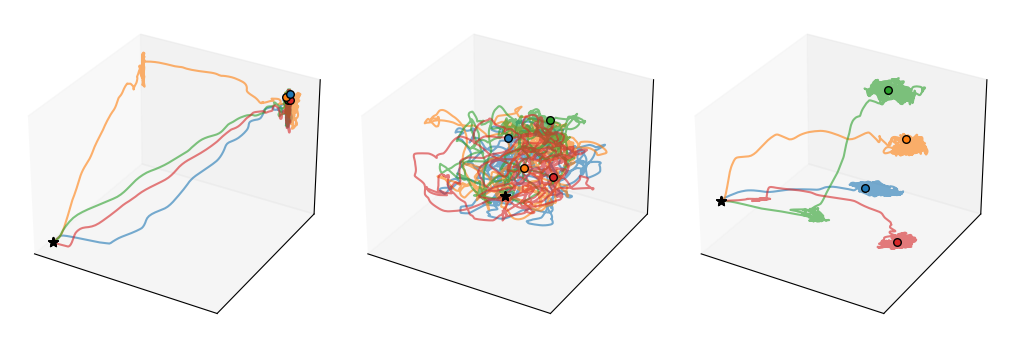

In [15]:
input_names = ['(-1,-1)', '(1,1)', '(-1,1)', '(1,-1)']

ticksize = 11
labelsize = 15

cue_idx = 1000
dim1, dim2, dim3 = 0,1,2

alpha=0.6

fig = plt.figure(figsize=(10,4), constrained_layout=True)
sim_idx1, sim_idx2, sim_idx3, sim_idx4 = 0, 1, 2, 3

config_list = [
    'cuedendnmdafast_Esomaampa_Edendampa',
    'cuedendampaslow_Esomaampa_Edendampa',
    'cuedendampa_Esomaampa_Edendampa_lowaxialres',
    ]


t_max = 1000
dt = 0.25 # simulation output downsampled by factor of 10
fs = (1/dt) * 1e3
time_vec = np.arange(0, t_max, dt)
downsample_factor = 10
burn_in = int(8000 / downsample_factor)

pca_dict = dict()
for plot_idx, name in enumerate(config_list):
    points1, points2, points3, points4, pca = get_pca_points(name, sim_idx1, sim_idx2, sim_idx3, sim_idx4)
    ax1 = fig.add_subplot(1,3,plot_idx+1, projection='3d')
    make_trajectory_figure(points1, points2, points3, points4, 0, cue_idx+2999, ax1, dim1, dim2, dim3,
                        color1='C0', color2='C1', color3='C2', color4='C3',
                        label1=input_names[sim_idx1], label2=input_names[sim_idx2], label3=input_names[sim_idx3], label4=input_names[sim_idx4],
                        alpha=alpha)
    
    pca_dict[name] = pca

figure_path = '/users/ntolley/data/ntolley/dendractor/memory_permutations/figures'
plt.savefig(f'{figure_path}/memory_receptor_dynamics_trajectory_panels.svg')
